# Analyse du questionnaire  Besoins en IA dans le secteur pharmaceutique

Ce notebook traite les réponses du questionnaire Google Forms diffusé dans le cadre du projet **Nexus**. L'objectif est de quantifier les besoins exprimés par les professionnels du secteur pharmaceutique en matière d'outils d'IA, et d'évaluer la pertinence d'une solution **100 % locale** comme Nexus face aux contraintes de confidentialité.


In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


Saving Besoins en outils IA dans le secteur pharmaceutique.csv (2).zip to Besoins en outils IA dans le secteur pharmaceutique.csv (2).zip


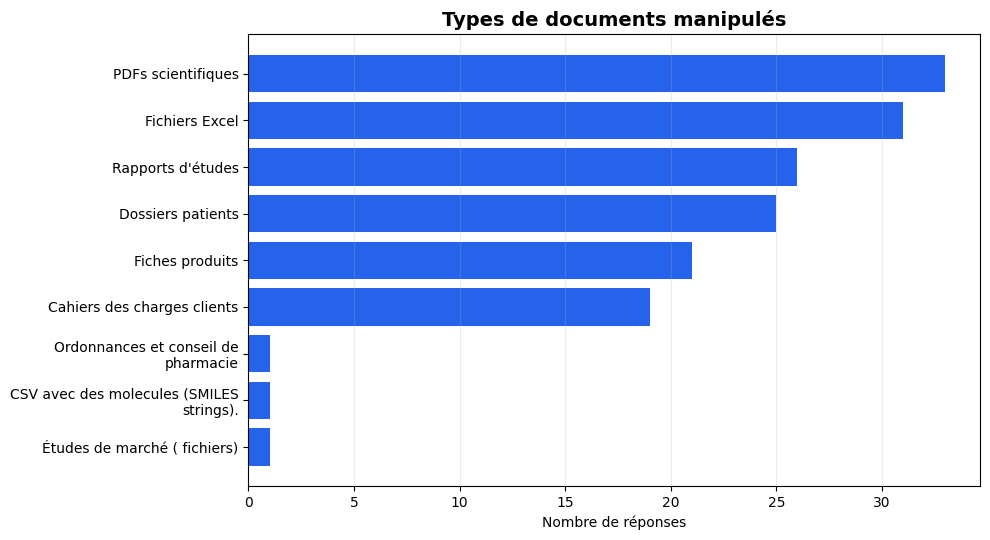

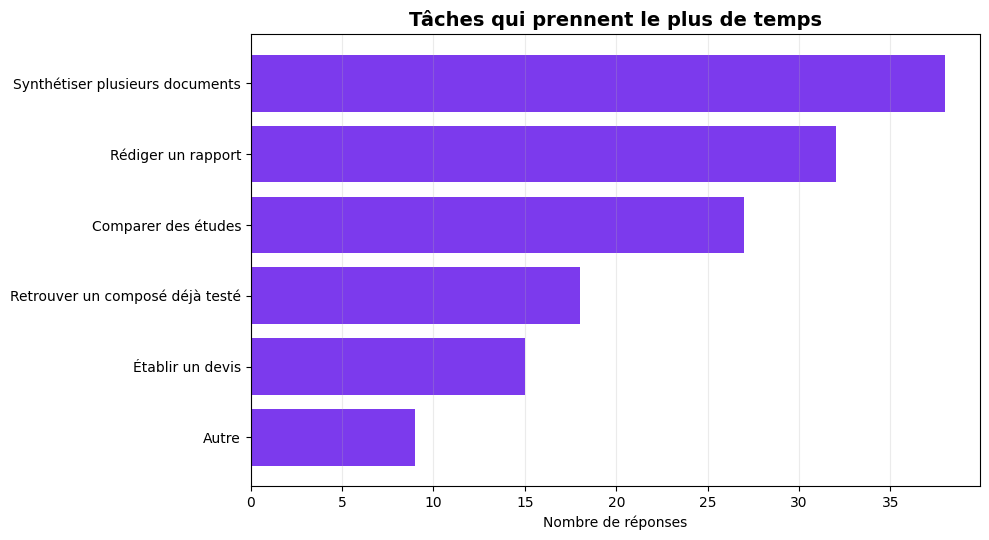

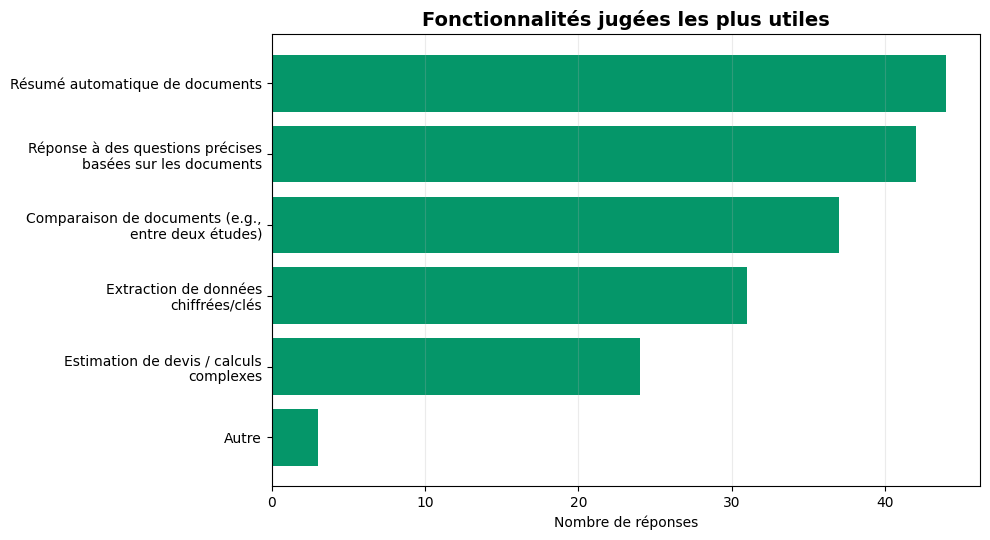

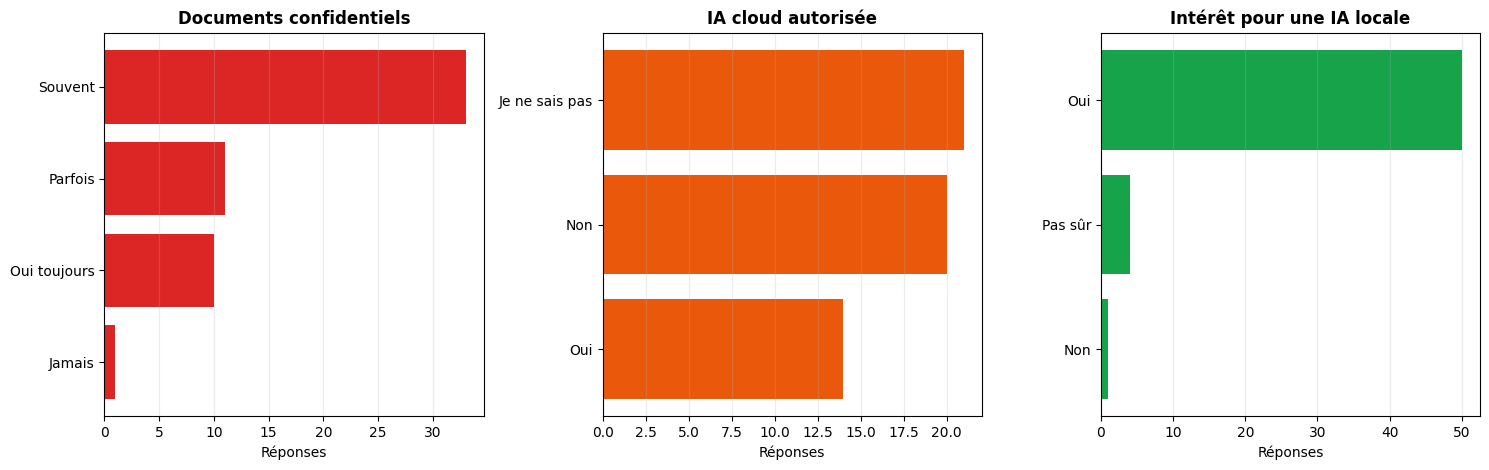

Images générées dans : /content/images_formulaire


In [ ]:
import zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

try:
    from google.colab import files
    uploaded = files.upload()
    ZIP_PATH = list(uploaded.keys())[0]
except:
    ZIP_PATH = "Besoins en outils IA dans le secteur pharmaceutique.csv.zip"

OUT_DIR = Path("images_formulaire")
OUT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    csv_name = [name for name in z.namelist() if name.endswith(".csv")][0]
    df = pd.read_csv(z.open(csv_name))

df.columns = [c.strip() for c in df.columns]

def find_col(part):
    for col in df.columns:
        if part.lower() in col.lower():
            return col
    raise ValueError(f"Colonne introuvable : {part}")

def count_multi(col):
    counts = {}
    for value in df[col].dropna():
        for item in str(value).split(";"):
            item = item.strip()
            if item:
                counts[item] = counts.get(item, 0) + 1
    return pd.Series(counts).sort_values(ascending=True)

def wrap_labels(labels, width=32):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]

def plot_barh(series, title, filename, color="#6d28d9"):
    plt.figure(figsize=(10, 5.5))
    labels = wrap_labels(series.index)
    plt.barh(labels, series.values, color=color)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Nombre de réponses")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

col_documents = find_col("types de documents")
col_taches = find_col("tâches vous prennent")
col_fonctionnalites = find_col("fonctionnalités vous seraient")
col_confidentiel = find_col("données confidentielles")
col_cloud = find_col("outil IA cloud")
col_local = find_col("100% en local")

documents = count_multi(col_documents)
taches = count_multi(col_taches)
fonctionnalites = count_multi(col_fonctionnalites)

plot_barh(
    documents,
    "Types de documents manipulés",
    "form_documents.png",
    color="#2563eb"
)

plot_barh(
    taches,
    "Tâches qui prennent le plus de temps",
    "form_taches.png",
    color="#7c3aed"
)

plot_barh(
    fonctionnalites,
    "Fonctionnalités jugées les plus utiles",
    "form_fonctionnalites.png",
    color="#059669"
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, col, title, color in [
    (axes[0], col_confidentiel, "Documents confidentiels", "#dc2626"),
    (axes[1], col_cloud, "IA cloud autorisée", "#ea580c"),
    (axes[2], col_local, "Intérêt pour une IA locale", "#16a34a"),
]:
    counts = df[col].value_counts().sort_values()
    ax.barh(wrap_labels(counts.index, width=22), counts.values, color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Réponses")
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / "form_confidentialite_local.png", dpi=200, bbox_inches="tight")
plt.show()

print("Images générées dans :", OUT_DIR.resolve())



## Conclusion

Les résultats du questionnaire confirment trois éléments structurants pour Nexus :

1. **Volume documentaire élevé** sur des formats que Nexus prend en charge (PDF, comptes-rendus).
2. **Tâches répétitives identifiées** comme cas d'usage prioritaires (rédaction, synthèse, recherche d'information).
3. **Contrainte forte de confidentialité** : une part significative des répondants ne peut pas recourir à une IA cloud, ce qui légitime une solution locale.
